In [ ]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
from konlpy.tag import Okt
import re


df = pd.read_csv("naver_news_250710_bert_fin_senti.csv")

okt = Okt()

# 텍스트 정제 및 명사 추출 함수
def extract_nouns(text):
    if pd.isna(text):
        return []
    text = re.sub(r'[^ㄱ-ㅎ가-힣\s]', '', text)  # 한글만 추출
    nouns = okt.nouns(text)
    # 불용어 제거
    stopwords = ['기자', '뉴스', '관련', '대한', '있다', '제공', '사진', '통해', '보도']
    return [word for word in nouns if len(word) > 1 and word not in stopwords]

# 산업군 목록
industries = df['predicted_industry'].dropna().unique()

# 워드클라우드 생성
def generate_wordcloud(words, font_path='/System/Library/Fonts/Supplemental/AppleGothic.ttf'):
    word_freq = Counter(words)
    wc = WordCloud(
        font_path=font_path,
        width=600,
        height=400,
        background_color='white',
        colormap='tab10'
    ).generate_from_frequencies(word_freq)
    return wc

# 산업군별 워드클라우드 생성
plt.figure(figsize=(20, 12))
for idx, industry in enumerate(sorted(industries)):
    industry_df = df[df['predicted_industry'] == industry]
    all_nouns = []
    for content in industry_df['content']:
        all_nouns.extend(extract_nouns(content))

    wc = generate_wordcloud(all_nouns)

    plt.subplot(3, 5, idx + 1)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(industry, fontsize=14)

plt.tight_layout()
plt.savefig(f"last_visualize/industry_wordcloud.png", dpi=300)
plt.show()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import matplotlib as mpl
import matplotlib.dates as mdates
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix


mpl.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

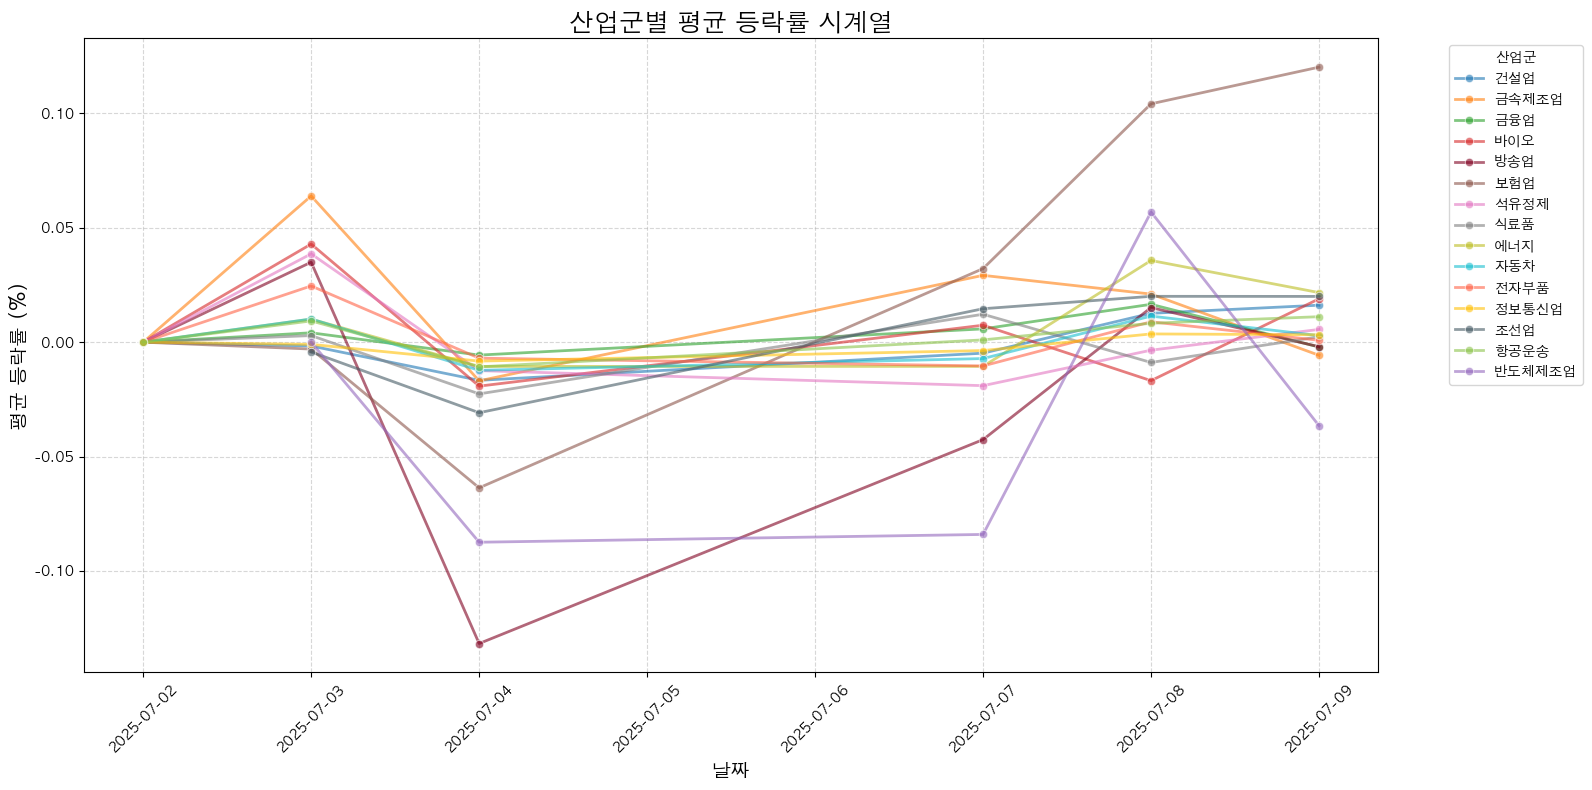

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

palette = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#800020' ,
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#ff6347', '#ffc107', '#455a64', '#8bc34a','#9467bd'
]

df = pd.read_csv("naver_news_250710_bert_fin_merged.csv")
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# 종가 수치 정제
df['close'] = pd.to_numeric(df['close'], errors='coerce')

# 종목별 등락률 계산
df = df.sort_values(['ticker', 'date'])
df['change_ratio'] = df.groupby('ticker')['close'].pct_change() * 100  # 퍼센트 등락률

# 산업군별 평균 등락률
grouped = (
    df.groupby(['date', 'industry'])['change_ratio']
    .mean()
    .reset_index()
)

# 시각화
plt.figure(figsize=(16, 8))
sns.lineplot(
    data=grouped,
    x='date',
    y='change_ratio',
    hue='industry',
    palette=palette,
    marker='o', alpha = 0.6, linewidth = 2
)
plt.title("산업군별 평균 등락률 시계열", fontsize=18)
plt.xlabel("날짜", fontsize=14)
plt.ylabel("평균 등락률 (%)", fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='산업군', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"last_visualize/industry_avg_close.png", dpi=300)
plt.show()

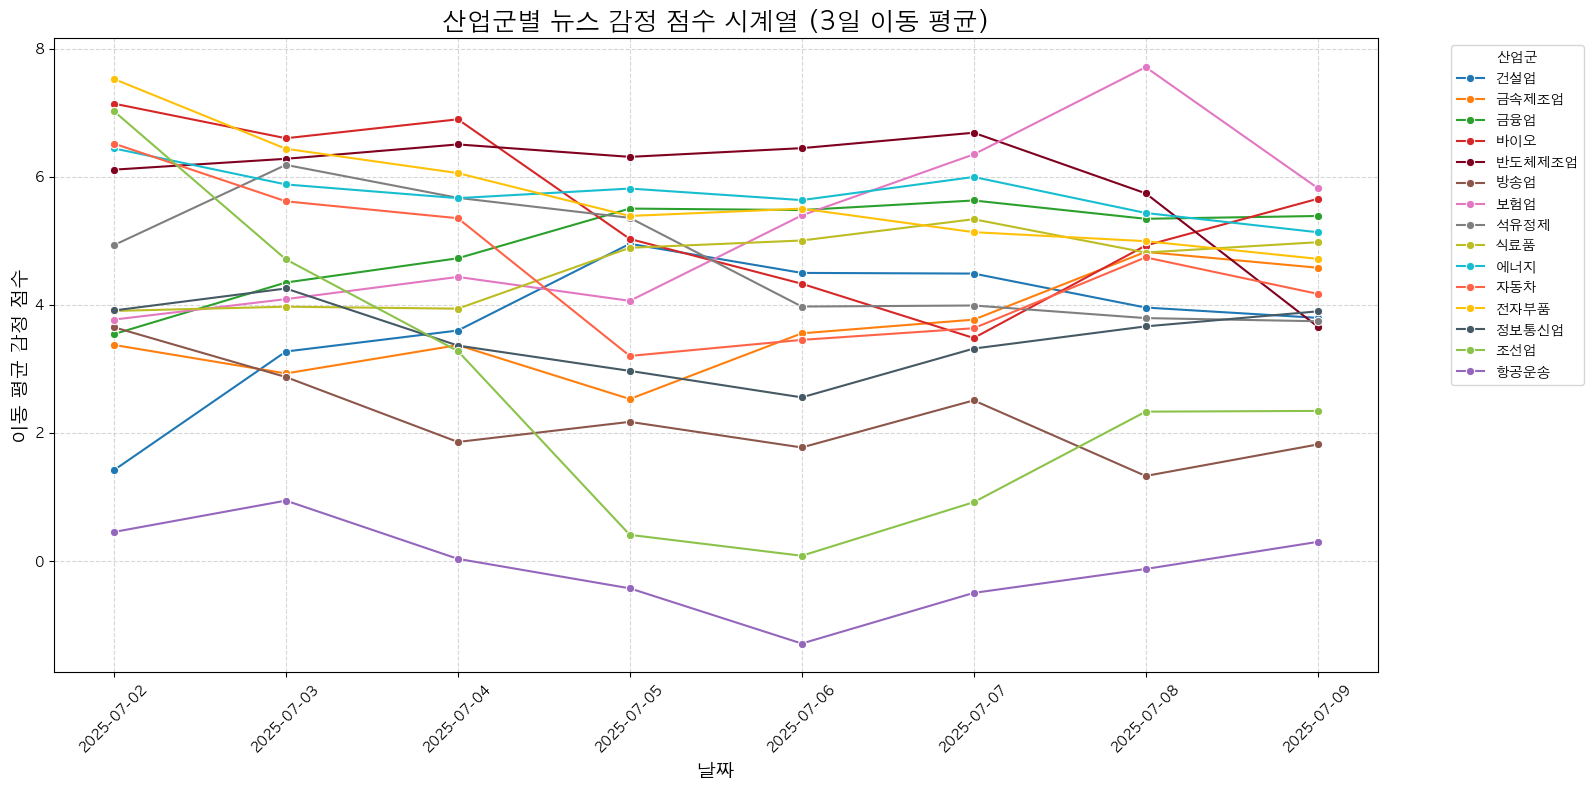

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

df = pd.read_csv("naver_news_250710_bert_fin_senti.csv")

palette = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#800020' ,
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#ff6347', '#ffc107', '#455a64', '#8bc34a','#9467bd'
]

# 날짜 파싱 함수
def clean_date(raw_date):
    if pd.isnull(raw_date):
        return None
    raw_date = str(raw_date)
    match = re.match(r"(\d{4})\.(\d{2})\.(\d{2})\.\s+(오전|오후)\s+(\d{1,2}):(\d{2})", raw_date)
    if match:
        year, month, day, ampm, hour, minute = match.groups()
        hour = int(hour)
        if ampm == '오후' and hour != 12:
            hour += 12
        elif ampm == '오전' and hour == 12:
            hour = 0
        return f"{year}-{month}-{day} {hour:02}:{minute}"
    return raw_date

df['date'] = df['date'].apply(clean_date)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['sentiment_score'] = pd.to_numeric(df['sentiment_score'], errors='coerce')
df['date'] = df['date'].dt.date

# 평균 감정 점수 계산
grouped = (
    df.groupby(['date', 'predicted_industry'])['sentiment_score']
    .mean()
    .reset_index()
)

# 이동평균 (추세 확인용, 3일 기준)
grouped['rolling_score'] = (
    grouped
    .groupby('predicted_industry')['sentiment_score']
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

# 시각화
plt.figure(figsize=(16, 8))
sns.lineplot(
    data=grouped,
    x='date',
    y='rolling_score',
    hue='predicted_industry',
    marker='o',
    palette=palette
)

plt.title("산업군별 뉴스 감정 점수 시계열 (3일 이동 평균)", fontsize=18)
plt.xlabel("날짜", fontsize=14)
plt.ylabel("이동 평균 감정 점수", fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='산업군', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"last_visualize/industry_sentiment_3daysavg.png", dpi=300)
plt.show()

In [ ]:
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

df = pd.read_csv("v3_news_2020_2025_06_combined.csv")
df['adjusted_date'] = pd.to_datetime(df['adjusted_date'], errors='coerce')
df = df.sort_values(by=['industry', 'adjusted_date'])

df['industry_avg_close'] = df.groupby(['industry', 'adjusted_date'])['close'].transform('mean')
df['industry_avg_foreign_vol'] = df.groupby(['industry', 'adjusted_date'])['foreign_vol'].transform('mean')
df['industry_avg_volume'] = df.groupby(['industry', 'adjusted_date'])['volume'].transform('mean')
df['score_change'] = df.groupby('industry')['normalized_score'].diff()
df['score_ma3'] = df.groupby('industry')['normalized_score'].rolling(3).mean().reset_index(0, drop=True)
df['score_ma5'] = df.groupby('industry')['normalized_score'].rolling(5).mean().reset_index(0, drop=True)
df['volatility'] = df.groupby('industry')['industry_avg_close'].rolling(3).std().reset_index(0, drop=True)

manual_weights = {
    '항공운송': {'normalized_score': 0.7, 'score_ma3': 0.1, 'volatility': 0.1, 'score_change': 0.1},
    '전자부품': {'normalized_score': 0.4, 'industry_avg_foreign_vol': 0.3, 'industry_avg_volume': 0.3},
    '바이오': {'score_ma5': 0.5, 'normalized_score': 0.3, 'volatility': 0.1, 'score_change': 0.1},
    '에너지': {'score_ma3': 0.5, 'normalized_score': 0.3, 'volatility': 0.2},
    '조선업': {'score_change': 0.4, 'normalized_score': 0.4, 'score_ma3': 0.2},
    '금속제조업': {'score_ma3': 0.3, 'score_change': 0.3, 'volatility': 0.2, 'normalized_score': 0.2},
    '반도체제조업': {'foreign_ratio': 0.3, 'score_change': 0.2, 'volatility': 0.2, 'score_ma3': 0.3},
    '자동차': {'normalized_score': 0.2, 'score_change': 0.6, 'score_ma3': 0.2},
    '정보통신업': {'normalized_score': 0.1, 'score_ma5': 0.8, 'score_change': 0.1},
    '건설업': {'normalized_score': 0.1, 'volatility': 0.1, 'score_ma5': 0.8},
    '석유정제': {'normalized_score': 0.2, 'score_ma5': 0.8},
    '금융업': {'normalized_score': 0.5, 'volume': 0.2, 'institution_vol': 0.15, 'foreign_vol': 0.15},
    '보험업': {'normalized_score': 0.3,'volume': 0.25, 'institution_vol': 0.2, 'foreign_ratio': 0.15, 'foreign_vol': 0.15},
    '식료품': {'normalized_score': 0.2, 'volume': 0.2, 'institution_vol': 0.1, 'foreign_vol': 0.1, 'foreign_ratio': 0.1, 'volatility': 0.1,'score_change': 0.1, 'score_ma3': 0.1},
    '방송업': {'normalized_score': 0.7,  'score_change': 0.3}
}

def get_model(industry, y_train=None):
    if industry in ['자동차', '정보통신업', '건설업', '석유정제', '금융업']:
        pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
        return CatBoostClassifier(random_seed=42, verbose=0, class_weights=[1, pos_weight])
    else:
        return LGBMClassifier(random_state=42, is_unbalance=True)

def get_t_shift(industry):
    return {'전자부품': 3, '정보통신업': 3}.get(industry, 1)

optimal_buy_data = {
    "industry": [
        "건설업", "금속제조업", "금융업", "바이오", "반도체제조업", "방송업", "보험업",
        "석유정제", "식료품", "에너지", "자동차", "전자부품", "정보통신업", "조선업", "항공운송"
    ],
    "T_buy": [
        0.1, 0.7, 0.4, 0.5, 0.2, 0.1, 0.2, 0.4, 0.1, 0.4, 0.6, 0.2, 0.1, 0.2, 0.4
    ]
}

In [ ]:
industry_colors = {
    '건설업': 'blue',
    '금속제조업': 'olive',
    '금융업': 'cyan',
    '바이오': 'orange',
    '반도체제조업': 'coral',
    '방송업': 'lime',
    '보험업': 'gold',
    '석유정제': 'magenta',
    '식료품': 'brown',
    '에너지': 'red',
    '자동차': 'navy',
    '전자부품': 'green',
    '정보통신업': 'teal',
    '조선업': 'purple',
    '항공운송': 'skyblue'
}

def plot_strategy_per_industry(df, optimal_buy_data):
    df['adjusted_date'] = pd.to_datetime(df['adjusted_date'], dayfirst=True, errors='coerce')
    df = df.sort_values(by=['industry', 'adjusted_date'])

    tbuy_map = dict(zip(optimal_buy_data['industry'], optimal_buy_data['T_buy']))

    # 파생 피처 생성
    df['industry_avg_close'] = df.groupby(['industry', 'adjusted_date'])['close'].transform('mean')
    df['industry_avg_foreign_vol'] = df.groupby(['industry', 'adjusted_date'])['foreign_vol'].transform('mean')
    df['industry_avg_volume'] = df.groupby(['industry', 'adjusted_date'])['volume'].transform('mean')
    df['score_change'] = df.groupby('industry')['normalized_score'].diff()
    df['score_ma3'] = df.groupby('industry')['normalized_score'].rolling(3).mean().reset_index(0, drop=True)
    df['score_ma5'] = df.groupby('industry')['normalized_score'].rolling(5).mean().reset_index(0, drop=True)
    df['volatility'] = df.groupby('industry')['industry_avg_close'].rolling(3).std().reset_index(0, drop=True)

    summary_data = []

    for industry in manual_weights.keys():
        if industry not in tbuy_map:
            continue

        weights = manual_weights[industry]
        sub = df[df['industry'] == industry].copy().dropna(subset=list(weights.keys()))
        if sub.empty:
            continue

        t_shift = get_t_shift(industry)
        sub['future_close'] = sub['industry_avg_close'].shift(-t_shift)
        sub['log_return'] = np.log(sub['future_close'] / sub['industry_avg_close'])

        sub['manual_weighted_score'] = sum(sub[feat] * w for feat, w in weights.items())
        sub = sub.dropna(subset=['manual_weighted_score', 'log_return'])

        train = sub[sub['adjusted_date'].dt.year < 2025].copy()
        test = sub[sub['adjusted_date'].dt.year == 2025].copy()

        if train.empty or test.empty:
            continue

        X_train = train[list(weights.keys())]
        y_train = (train['log_return'] > 0.01).astype(int)
        X_test = test[list(weights.keys())]

        model = get_model(industry, y_train)
        model.fit(X_train, y_train)

        proba = model.predict_proba(X_test)[:, 1]
        T_buy = tbuy_map[industry]
        test['pred'] = (proba > T_buy).astype(int)  #구매

        test['strategy_return'] = test['log_return'] * test['pred']
        test['cum_strategy_return'] = test['strategy_return'].cumsum()
        test['cum_hold_return'] = test['log_return'].cumsum()

        # 초과 수익률 계산
        excess_return = test['cum_strategy_return'].iloc[-1] - test['cum_hold_return'].iloc[-1]
        daily_excess_mean = (test['strategy_return'] - test['log_return']).mean()
        summary_data.append({
            'industry': industry,
            't_shift': t_shift,
            'T_buy': T_buy,
            'excess_return': excess_return,
            'daily_excess_mean': daily_excess_mean
        })

        # 그래프
        plt.figure(figsize=(8, 4))
        strategy_color = industry_colors.get(industry, 'blue')
        plt.plot(test['adjusted_date'], test['cum_strategy_return'], label='전략', color=strategy_color)
        plt.plot(test['adjusted_date'], test['cum_hold_return'], label='보유', color='dimgray', linestyle='--', alpha=0.8)
        plt.title(f"{industry} : 보유vs전략 (T_buy={T_buy}) 6개월(2025.01~06)", fontsize=14)
        plt.axhline(0, linestyle='--', color='black', alpha=0.2)
        plt.xlabel("날짜")
        plt.ylabel("누적 수익률")
        plt.grid(True)
        plt.legend()
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(f"6month/{industry}_strategy_6month.png")
        plt.close()

    # 결과 요약 테이블 출력
    summary_df = pd.DataFrame(summary_data)
    summary_df = summary_df.sort_values(by='excess_return', ascending=False)
    print(summary_df[['industry', 'excess_return', 'daily_excess_mean']])

    # 최대, 평균 초과 수익률
    max_row = summary_df.iloc[0]
    avg_excess = summary_df['excess_return'].mean()
    print(f"\n최대 초과 수익률: +{max_row['excess_return']:.2%} (T+{max_row['t_shift']}, {max_row['industry']})")
    print(f"평균 초과 수익률: +{avg_excess:.2%}")


In [ ]:
result = plot_strategy_per_industry(df, optimal_buy_data)

[LightGBM] [Info] Number of positive: 161, number of negative: 4169
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000228 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 971
[LightGBM] [Info] Number of data points in the train set: 4330, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.037182 -> initscore=-3.254027
[LightGBM] [Info] Start training from score -3.254027
[LightGBM] [Info] Number of positive: 636, number of negative: 13004
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000175 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 752
[LightGBM] [Info] Number of data points in the train set: 13640, number of used features: 3
[LightGBM] [Info] [binary:Bo

In [ ]:
summary_df.to_csv("strategy_excess_summary.csv", index=False)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

industry_colors = {
    '건설업': 'blue',
    '금속제조업': 'olive',
    '금융업': 'cyan',
    '바이오': 'orange',
    '반도체제조업': 'coral',
    '방송업': 'lime',
    '보험업': 'gold',
    '석유정제': 'magenta',
    '식료품': 'brown',
    '에너지': 'red',
    '자동차': 'navy',
    '전자부품': 'green',
    '정보통신업': 'teal',
    '조선업': 'purple',
    '항공운송': 'skyblue'
}

def plot_strategy_per_industry(df, optimal_buy_data):
    df['adjusted_date'] = pd.to_datetime(df['adjusted_date'], dayfirst=True, errors='coerce')
    df = df.sort_values(by=['industry', 'adjusted_date'])

    tbuy_map = dict(zip(optimal_buy_data['industry'], optimal_buy_data['T_buy']))

    # 파생 피처 생성
    df['industry_avg_close'] = df.groupby(['industry', 'adjusted_date'])['close'].transform('mean')
    df['industry_avg_foreign_vol'] = df.groupby(['industry', 'adjusted_date'])['foreign_vol'].transform('mean')
    df['industry_avg_volume'] = df.groupby(['industry', 'adjusted_date'])['volume'].transform('mean')
    df['score_change'] = df.groupby('industry')['normalized_score'].diff()
    df['score_ma3'] = df.groupby('industry')['normalized_score'].rolling(3).mean().reset_index(0, drop=True)
    df['score_ma5'] = df.groupby('industry')['normalized_score'].rolling(5).mean().reset_index(0, drop=True)
    df['volatility'] = df.groupby('industry')['industry_avg_close'].rolling(3).std().reset_index(0, drop=True)

    summary_data = []

    for industry in manual_weights.keys():
        if industry not in tbuy_map:
            continue

        weights = manual_weights[industry]
        sub = df[df['industry'] == industry].copy().dropna(subset=list(weights.keys()))
        if sub.empty:
            continue

        t_shift = get_t_shift(industry)
        sub['future_close'] = sub['industry_avg_close'].shift(-t_shift)
        sub['log_return'] = np.log(sub['future_close'] / sub['industry_avg_close'])

        sub['manual_weighted_score'] = sum(sub[feat] * w for feat, w in weights.items())
        sub = sub.dropna(subset=['manual_weighted_score', 'log_return'])

        train = sub[sub['adjusted_date'].dt.year < 2025].copy()
        test = sub[sub['adjusted_date'].dt.year == 2025].copy()

        if train.empty or test.empty:
            continue

        X_train = train[list(weights.keys())]
        y_train = (train['log_return'] > 0.01).astype(int)
        X_test = test[list(weights.keys())]

        model = get_model(industry, y_train)
        model.fit(X_train, y_train)

        proba = model.predict_proba(X_test)[:, 1]
        T_buy = tbuy_map[industry]
        test['pred'] = (proba > T_buy).astype(int)

        test['strategy_return'] = test['log_return'] * test['pred']
        test['cum_strategy_return'] = test['strategy_return'].cumsum()
        test['cum_hold_return'] = test['log_return'].cumsum()

        # 수익률 계산 및 저장
        strategy_return = test['cum_strategy_return'].iloc[-1]
        held_return = test['cum_hold_return'].iloc[-1]
        excess_return = strategy_return - held_return
        daily_excess_mean = (test['strategy_return'] - test['log_return']).mean()
        excess_percent = (excess_return / strategy_return) * 100 if strategy_return != 0 else 0

        summary_data.append({
            'industry': industry,
            'strategy_return': round(strategy_return, 4),
            'held_return': round(held_return, 4),
            'excess_return': round(excess_return, 4),
            't_shift': t_shift,
            'excess_percent': round(excess_percent, 2)
        })

        # 그래프
        plt.figure(figsize=(8, 4))
        strategy_color = industry_colors.get(industry, 'blue')
        plt.plot(test['adjusted_date'], test['cum_strategy_return'], label='전략', color=strategy_color)
        plt.plot(test['adjusted_date'], test['cum_hold_return'], label='보유', color='dimgray', linestyle='--', alpha=0.8)
        plt.title(f"{industry} : 보유vs전략 (T_buy={T_buy}) 6개월(2025.01~06)", fontsize=14)
        plt.axhline(0, linestyle='--', color='black', alpha=0.2)
        plt.xlabel("날짜")
        plt.ylabel("누적 수익률")
        plt.grid(True)
        plt.legend()
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(f"6month/{industry}_strategy_6month.png")
        plt.close()

    # 요약 테이블 출력
    summary_df = pd.DataFrame(summary_data)
    summary_df = summary_df.sort_values(by='excess_return', ascending=False)

    display_cols = ['industry', 'strategy_return', 'held_return', 'excess_return', 't_shift', 'excess_percent']
    print(summary_df[display_cols])

    # 최고 & 평균 초과 수익률
    max_row = summary_df.iloc[0]
    avg_excess = summary_df['excess_return'].mean()
    print(f"\n최대 초과 수익률: +{max_row['excess_return']:.2%} (T+{max_row['t_shift']}, {max_row['industry']})")
    print(f"평균 초과 수익률: +{avg_excess:.2%}")

    # 저장
    summary_df.to_csv("summary_strategy_vs_hold.csv", index=False)


In [ ]:
result2 = plot_strategy_per_industry(df, optimal_buy_data)

[LightGBM] [Info] Number of positive: 161, number of negative: 4169
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000169 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 971
[LightGBM] [Info] Number of data points in the train set: 4330, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.037182 -> initscore=-3.254027
[LightGBM] [Info] Start training from score -3.254027
[LightGBM] [Info] Number of positive: 636, number of negative: 13004
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000227 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 752
[LightGBM] [Info] Number of data points in the train set: 13640, number of used features: 3
[LightGBM] [Info] [binary:Bo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import matplotlib as mpl

mpl.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 자연어 시점 변환 함수
def shift_to_korean(t):
    if t == 1:
        return "내일"
    elif t == 2:
        return "모레"
    else:
        return f"{t}일 후"

# 1. 데이터 불러오기
df = pd.read_csv("naver_news_250710_bert_fin_merged.csv")
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.sort_values(by=['industry', 'date'])

# 2. 파생 피처 생성
df['industry_avg_close'] = df.groupby(['industry', 'date'])['close'].transform('mean')
df['industry_avg_foreign_vol'] = df.groupby(['industry', 'date'])['foreign_vol'].transform('mean')
df['industry_avg_volume'] = df.groupby(['industry', 'date'])['volume'].transform('mean')
df['score_change'] = df.groupby('industry')['normalized_score'].diff()
df['score_ma3'] = df.groupby('industry')['normalized_score'].rolling(3).mean().reset_index(0, drop=True)
df['score_ma5'] = df.groupby('industry')['normalized_score'].rolling(5).mean().reset_index(0, drop=True)
df['volatility'] = df.groupby('industry')['industry_avg_close'].rolling(3).std().reset_index(0, drop=True)

# 3. manual_weights 설정
manual_weights = {
    '항공운송': {'normalized_score': 0.7, 'score_ma3': 0.1, 'volatility': 0.1, 'score_change': 0.1},
    '전자부품': {'normalized_score': 0.4, 'industry_avg_foreign_vol': 0.3, 'industry_avg_volume': 0.3},
    '바이오': {'score_ma5': 0.5, 'normalized_score': 0.3, 'volatility': 0.1, 'score_change': 0.1},
    '에너지': {'score_ma3': 0.5, 'normalized_score': 0.3, 'volatility': 0.2},
    '조선업': {'score_change': 0.4, 'normalized_score': 0.4, 'score_ma3': 0.2},
    '금속제조업': {'score_ma3': 0.3, 'score_change': 0.3, 'volatility': 0.2, 'normalized_score': 0.2},
    '반도체제조업': {'foreign_ratio': 0.3, 'score_change': 0.2, 'volatility': 0.2, 'score_ma3': 0.3},
    '자동차': {'normalized_score': 0.2, 'score_change': 0.6, 'score_ma3': 0.2},
    '정보통신업': {'normalized_score': 0.1, 'score_ma5': 0.8, 'score_change': 0.1},
    '건설업': {'normalized_score': 0.1, 'volatility': 0.1, 'score_ma5': 0.8},
    '석유정제': {'normalized_score': 0.2, 'score_ma5': 0.8},
    '금융업': {'normalized_score': 0.5, 'volume': 0.2, 'institution_vol': 0.15, 'foreign_vol': 0.15},
    '보험업': {'normalized_score': 0.3, 'volume': 0.25, 'institution_vol': 0.2, 'foreign_ratio': 0.15, 'foreign_vol': 0.15},
    '식료품': {'normalized_score': 0.2, 'volume': 0.2, 'institution_vol': 0.1, 'foreign_vol': 0.1, 'foreign_ratio': 0.1, 'volatility': 0.1, 'score_change': 0.1, 'score_ma3': 0.1},
    '방송업': {'normalized_score': 0.7, 'score_change': 0.3}
}

# 4. 산업군별 모델 선택
def get_model(industry, y_train=None):
    if industry in ['자동차', '정보통신업', '건설업', '석유정제', '금융업']:
        pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
        return CatBoostClassifier(random_seed=42, verbose=0, class_weights=[1, pos_weight])
    else:
        return LGBMClassifier(random_state=42, is_unbalance=True)

# 5. 산업군별 시차 설정
def get_t_shift(industry):
    return {'전자부품': 3, '정보통신업': 3}.get(industry, 1)

# 6. 예측 결과 저장
results = []

for industry, weights in manual_weights.items():
    features = list(weights.keys())
    sub = df[df['industry'] == industry].copy()
    sub = sub.dropna(subset=features)
    if sub.empty:
        continue

    t_shift = get_t_shift(industry)
    sub['future_close'] = sub['industry_avg_close'].shift(-t_shift)
    sub['log_return'] = np.log(sub['future_close'] / sub['industry_avg_close'])
    sub['label'] = (sub['log_return'] > 0.01).astype(int)

    train = sub[sub['date'] < '2025-07-09']
    test = sub[sub['date'] == '2025-07-09']

    if train.empty or test.empty:
        continue

    X_train = train[features]
    y_train = train['label']
    X_test = test[features]

    if len(y_train.unique()) == 1:
        print(f"{industry}: y_train 단일 클래스 — 모델 학습 생략")
        continue

    model = get_model(industry, y_train)
    model.fit(X_train, y_train)

    probas = model.predict_proba(X_test)[:, 1]
    avg_proba = np.mean(probas)

    results.append({
        'industry': industry,
        'predicted_prob': avg_proba * 100
    })

# 7. 기준 매수 확률 설정
optimal_buy_data = {
    "industry": [
        "건설업", "금속제조업", "금융업", "바이오", "반도체제조업", "방송업", "보험업",
        "석유정제", "식료품", "에너지", "자동차", "전자부품", "정보통신업", "조선업", "항공운송"
    ],
    "T_buy": [
        0.1, 0.7, 0.4, 0.5, 0.2, 0.1, 0.2, 0.4, 0.1, 0.4, 0.6, 0.2, 0.1, 0.2, 0.4
    ]
}
optimal_df = pd.DataFrame(optimal_buy_data)
pred_df = pd.DataFrame(results)

# 8. 병합
merged = pd.merge(optimal_df, pred_df, on='industry', how='left')
merged['predicted_prob'] = merged['predicted_prob'].fillna(0)

# 9. 산업군별 표 출력
for _, row in merged.iterrows():
    industry = row['industry']
    pred_prob = row['predicted_prob']
    T_buy = row['T_buy']

    t_shift = get_t_shift(industry)
    update_date = pd.to_datetime("2025-07-09")
    target_date = update_date + pd.Timedelta(days=t_shift)

    shift_text = shift_to_korean(t_shift)
    예측대상일 = f"{shift_text}({target_date.strftime('%m.%d')})"

    상승확률 = f"{pred_prob:.1f}%" if pred_prob > 0 else '–'
    매수기준 = f"{T_buy * 100:.1f}%"
    충족여부 = '충족' if pred_prob > (T_buy * 100) else '미충족'

    table_data = [[industry,
                   update_date.strftime("%Y-%m-%d"),
                   예측대상일,
                   상승확률,
                   매수기준,
                   충족여부]]

    col_labels = ["산업군", "업데이트 날짜", "예측 대상일", f"{shift_text} 상승 확률", "매수 추천 기준", "기준 충족 여부"]

    fig, ax = plt.subplots(figsize=(8, 2.5))
    ax.axis('off')

    tbl = ax.table(cellText=table_data,
                   colLabels=col_labels,
                   colColours=['#e8f0fe'] * len(col_labels),
                   cellLoc='center',
                   loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.2, 1.5)

    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_text_props(weight='bold', color='black')
        else:
            cell.set_facecolor('white')
        cell.set_linewidth(1)

    plt.savefig(
    f"folder/{industry}_{update_date.strftime("%Y-%m-%d")}_tbl.png",
    dpi=300,
    bbox_inches='tight',
    bbox_extra_artists=[tbl],
    pad_inches=0  # 여백 제거
)
    plt.close()


[LightGBM] [Info] Number of positive: 2, number of negative: 2171
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000076 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 654
[LightGBM] [Info] Number of data points in the train set: 2173, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000920 -> initscore=-6.989796
[LightGBM] [Info] Start training from score -6.989796
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [ ]:
# 파라미터 조정 전 !

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

mpl.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

manual_weights = {
    '항공운송': {'normalized_score': 0.7, 'score_ma3': 0.1, 'volatility': 0.1, 'score_change': 0.1},
    '전자부품': {'normalized_score': 0.4, 'industry_avg_foreign_vol': 0.3, 'industry_avg_volume': 0.3},
    '바이오': {'score_ma5': 0.5, 'normalized_score': 0.3, 'volatility': 0.1, 'score_change': 0.1},
    '에너지': {'score_ma3': 0.5, 'normalized_score': 0.3, 'volatility': 0.2},
    '조선업': {'score_change': 0.4, 'normalized_score': 0.4, 'score_ma3': 0.2},
    '금속제조업': {'score_ma3': 0.3, 'score_change': 0.3, 'volatility': 0.2, 'normalized_score': 0.2},
    '반도체제조업': {'foreign_ratio': 0.3, 'score_change': 0.2, 'volatility': 0.2, 'score_ma3': 0.3},
    '자동차': {'normalized_score': 0.2, 'score_change': 0.6, 'score_ma3': 0.2},
    '정보통신업': {'normalized_score': 0.1, 'score_ma5': 0.8, 'score_change': 0.1},
    '건설업': {'normalized_score': 0.1, 'volatility': 0.1, 'score_ma5': 0.8},
    '석유정제': {'normalized_score': 0.2, 'score_ma5': 0.8},
    '금융업': {'normalized_score': 0.5, 'volume': 0.2, 'institution_vol': 0.15, 'foreign_vol': 0.15},
    '보험업': {'normalized_score': 0.3,'volume': 0.25, 'institution_vol': 0.2, 'foreign_ratio': 0.15, 'foreign_vol': 0.15},
    '식료품': {'normalized_score': 0.2, 'volume': 0.2, 'institution_vol': 0.1, 'foreign_vol': 0.1, 'foreign_ratio': 0.1, 'volatility': 0.1,'score_change': 0.1, 'score_ma3': 0.1},
    '방송업': {'normalized_score': 0.7,  'score_change': 0.3}
}

industry_colors = {
    '항공운송': '#1f77b4', '전자부품': '#ff7f0e', '바이오': '#2ca02c', '에너지': '#d62728',
    '조선업': '#9467bd', '금속제조업': '#8c564b', '반도체제조업': '#e377c2', '자동차': '#7f7f7f',
    '정보통신업': '#bcbd22', '건설업': '#17becf', '석유정제': '#aec7e8', '금융업': '#ffbb78',
    '보험업': '#98df8a', '식료품': '#ff9896', '방송업': '#c5b0d5'
}

def get_model(industry, y_train=None):
    if industry in ['자동차', '정보통신업', '건설업', '석유정제', '금융업']:
        pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
        return CatBoostClassifier(
            random_seed=42,
            verbose=0,
            class_weights=[1, pos_weight],
            depth=4
        )
    else:
        return LGBMClassifier(
            random_state=42,
            is_unbalance=True,
            max_depth=3, verbose=-1
        )


def get_t_shift(industry):
    return {'전자부품': 3, '정보통신업': 3}.get(industry, 1)



def evaluate_model_no_plot(df, optimal_buy_data):
    df['adjusted_date'] = pd.to_datetime(df['adjusted_date'], dayfirst=True, errors='coerce')
    df = df.sort_values(by=['industry', 'adjusted_date'])

    tbuy_map = dict(zip(optimal_buy_data['industry'], optimal_buy_data['T_buy']))

    df['industry_avg_close'] = df.groupby(['industry', 'adjusted_date'])['close'].transform('mean')
    df['industry_avg_foreign_vol'] = df.groupby(['industry', 'adjusted_date'])['foreign_vol'].transform('mean')
    df['industry_avg_volume'] = df.groupby(['industry', 'adjusted_date'])['volume'].transform('mean')
    df['score_change'] = df.groupby('industry')['normalized_score'].diff()
    df['score_ma3'] = df.groupby('industry')['normalized_score'].rolling(3).mean().reset_index(0, drop=True)
    df['score_ma5'] = df.groupby('industry')['normalized_score'].rolling(5).mean().reset_index(0, drop=True)
    df['volatility'] = df.groupby('industry')['industry_avg_close'].rolling(3).std().reset_index(0, drop=True)

    industries = list(manual_weights.keys())
    records = []  # ← 결과 누적용 리스트

    for industry in industries:
        weights = manual_weights[industry]
        sub = df[df['industry'] == industry].copy().dropna(subset=list(weights.keys()))
        if sub.empty or industry not in tbuy_map:
            continue

        t_shift = get_t_shift(industry)
        sub['future_close'] = sub['industry_avg_close'].shift(-t_shift)
        sub['log_return'] = np.log(sub['future_close'] / sub['industry_avg_close'])
        sub['manual_weighted_score'] = sum(sub[feat] * w for feat, w in weights.items())
        sub = sub.dropna(subset=['manual_weighted_score', 'log_return'])

        train = sub[sub['adjusted_date'].dt.year < 2025].copy()
        test = sub[sub['adjusted_date'].dt.year == 2025].copy()
        if train.empty or test.empty:
            continue

        X_train = train[list(weights.keys())]
        y_train = (train['log_return'] > 0.01).astype(int)
        X_test = test[list(weights.keys())]
        y_test = (test['log_return'] > 0.01).astype(int)

        model = get_model(industry, y_train)
        model.fit(X_train, y_train)

        T_buy = tbuy_map[industry]
        train_proba = model.predict_proba(X_train)[:, 1]
        test_proba = model.predict_proba(X_test)[:, 1]
        train_pred = (train_proba > T_buy).astype(int)
        test_pred = (test_proba > T_buy).astype(int)

        train_acc = accuracy_score(y_train, train_pred)
        test_acc = accuracy_score(y_test, test_pred)
        train_auc = roc_auc_score(y_train, train_proba)
        test_auc = roc_auc_score(y_test, test_proba)

        records.append({
            'industry': industry,
            'T_buy': T_buy,
            'train_acc': train_acc,
            'train_auc': train_auc,
            'test_acc': test_acc,
            'test_auc': test_auc
        })

    # DataFrame 생성
    result = pd.DataFrame(records)
    return result

# T_buy 데이터
optimal_buy_data = {
    "industry": [
        "건설업", "금속제조업", "금융업", "바이오", "반도체제조업", "방송업", "보험업",
        "석유정제", "식료품", "에너지", "자동차", "전자부품", "정보통신업", "조선업", "항공운송"
    ],
    "T_buy": [
        0.1, 0.7, 0.4, 0.5, 0.2, 0.1, 0.2, 0.4, 0.1, 0.4, 0.6, 0.2, 0.1, 0.2, 0.4
    ]
}


df = pd.read_csv('v3_news_2020_2025_06_combined.csv')
pre_results_df = evaluate_model_no_plot(df, optimal_buy_data)
pre_results_df.to_csv("pre_tuned_results.csv", index=False)


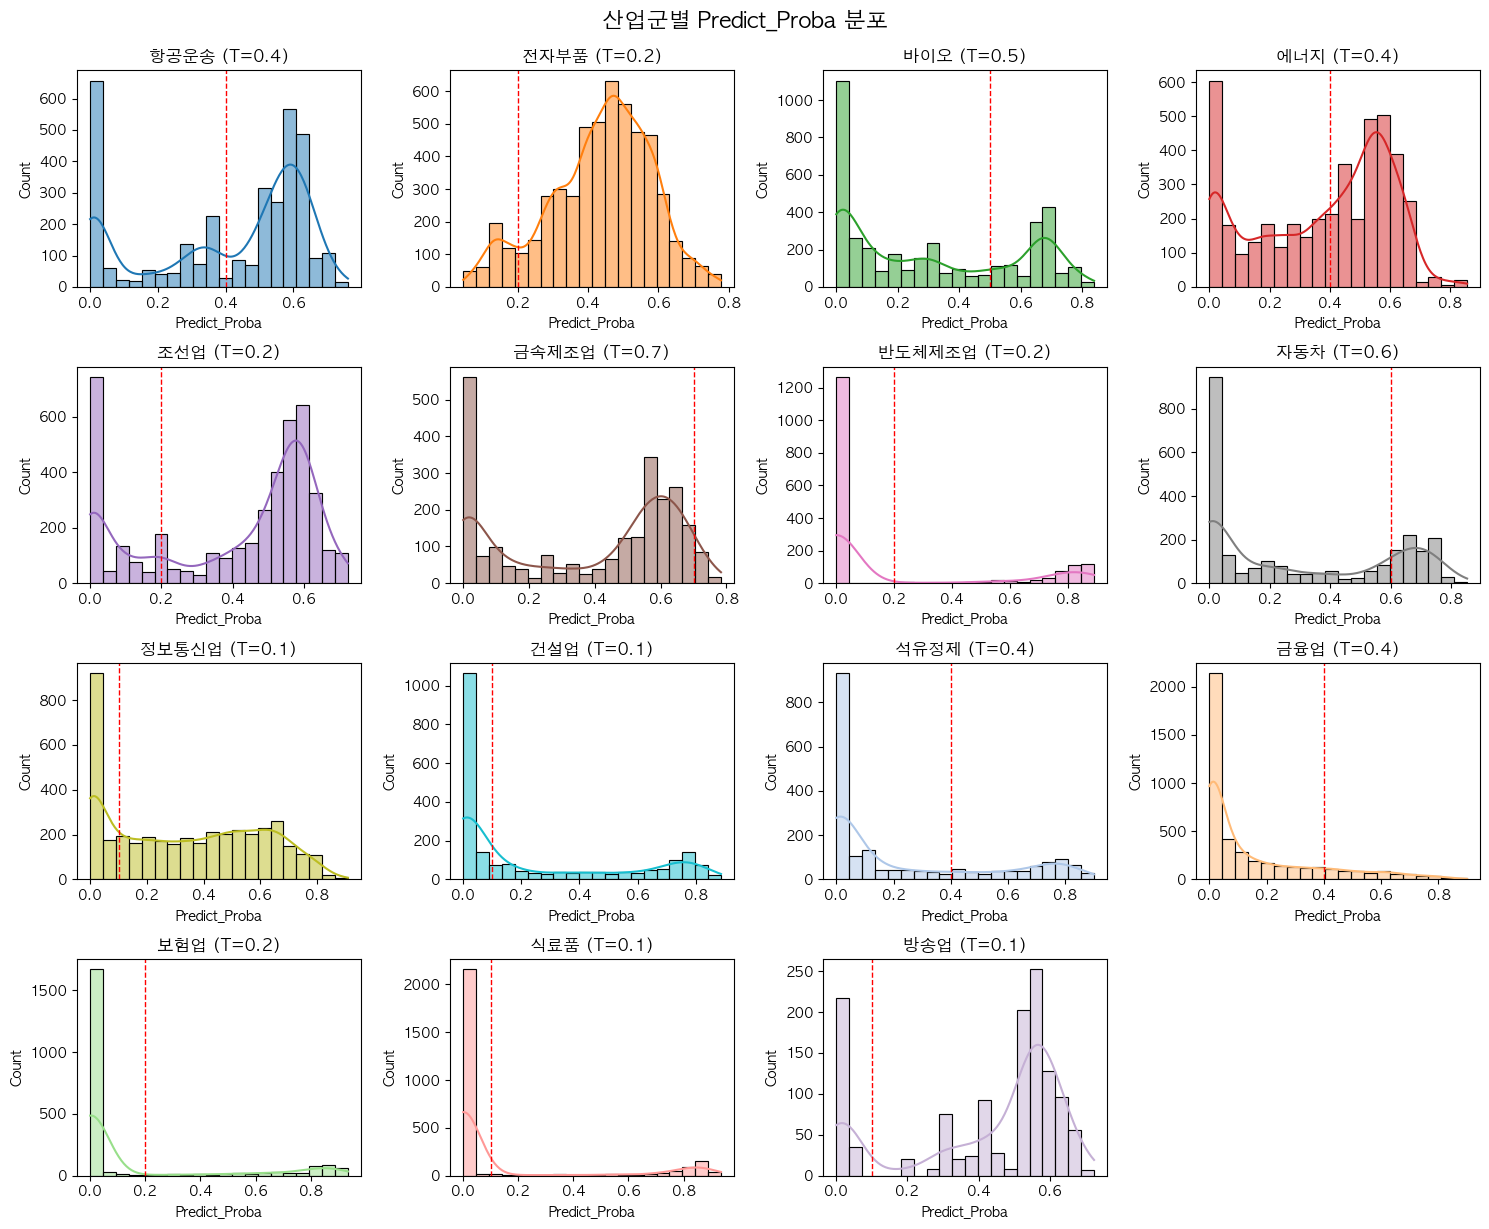

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_proba_distribution(df, optimal_buy_data):
    df['adjusted_date'] = pd.to_datetime(df['adjusted_date'], errors='coerce')
    df = df.sort_values(by=['industry', 'adjusted_date'])

    df['industry_avg_close'] = df.groupby(['industry', 'adjusted_date'])['close'].transform('mean')
    df['industry_avg_foreign_vol'] = df.groupby(['industry', 'adjusted_date'])['foreign_vol'].transform('mean')
    df['industry_avg_volume'] = df.groupby(['industry', 'adjusted_date'])['volume'].transform('mean')
    df['score_change'] = df.groupby('industry')['normalized_score'].diff()
    df['score_ma3'] = df.groupby('industry')['normalized_score'].rolling(3).mean().reset_index(0, drop=True)
    df['score_ma5'] = df.groupby('industry')['normalized_score'].rolling(5).mean().reset_index(0, drop=True)
    df['volatility'] = df.groupby('industry')['industry_avg_close'].rolling(3).std().reset_index(0, drop=True)

    tbuy_map = dict(zip(optimal_buy_data['industry'], optimal_buy_data['T_buy']))

    industries = list(manual_weights.keys())
    plt.figure(figsize=(15, 12))

    for idx, industry in enumerate(industries, 1):
        weights = manual_weights[industry]
        sub = df[df['industry'] == industry].copy().dropna(subset=list(weights.keys()))
        if sub.empty or industry not in tbuy_map:
            continue

        t_shift = get_t_shift(industry)
        sub['future_close'] = sub['industry_avg_close'].shift(-t_shift)
        sub['log_return'] = np.log(sub['future_close'] / sub['industry_avg_close'])
        sub = sub.dropna(subset=['log_return'])

        train = sub[sub['adjusted_date'].dt.year < 2025].copy()
        test = sub[sub['adjusted_date'].dt.year == 2025].copy()
        if train.empty or test.empty:
            continue

        X_train = train[list(weights.keys())]
        y_train = (train['log_return'] > 0.01).astype(int)
        X_test = test[list(weights.keys())]

        model = get_model(industry, y_train)
        model.fit(X_train, y_train)
        probas = model.predict_proba(X_test)[:, 1]

        plt.subplot(4, 4, idx)
        sns.histplot(probas, bins=20, kde=True, color=industry_colors.get(industry, 'gray'))
        plt.axvline(tbuy_map[industry], color='red', linestyle='--', linewidth=1)
        plt.title(f"{industry} (T={tbuy_map[industry]})")
        plt.xlabel("Predict_Proba")
        plt.ylabel("Count")

    plt.tight_layout()
    plt.suptitle("산업군별 Predict_Proba 분포", fontsize=16, y=1.02)
    plt.show()

# 실행
plot_proba_distribution(df, optimal_buy_data)

In [ ]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
from konlpy.tag import Okt
import re


df = pd.read_csv("naver_news_250710_bert_fin_senti.csv")

okt = Okt()

# 텍스트 정제 및 명사 추출 함수
def extract_nouns(text):
    if pd.isna(text):
        return []
    text = re.sub(r'[^ㄱ-ㅎ가-힣\s]', '', text)  # 한글만 추출
    nouns = okt.nouns(text)
    # 불용어 제거
    stopwords = ['기자', '뉴스', '관련', '대한', '있다', '제공', '사진', '통해', '보도']
    return [word for word in nouns if len(word) > 1 and word not in stopwords]

# 산업군 목록
industries = df['predicted_industry'].dropna().unique()

# 워드클라우드 생성
def generate_wordcloud(words, font_path='/System/Library/Fonts/Supplemental/AppleGothic.ttf'):
    word_freq = Counter(words)
    wc = WordCloud(
        font_path=font_path,
        width=600,
        height=400,
        background_color='white',
        colormap='tab10'
    ).generate_from_frequencies(word_freq)
    return wc

# 산업군별 워드클라우드 생성
plt.figure(figsize=(20, 12))
for idx, industry in enumerate(sorted(industries)):
    industry_df = df[df['predicted_industry'] == industry]
    all_nouns = []
    for content in industry_df['content']:
        all_nouns.extend(extract_nouns(content))

    wc = generate_wordcloud(all_nouns)

    plt.subplot(3, 5, idx + 1)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(industry, fontsize=14)

plt.tight_layout()
plt.savefig(f"last_visualize/industry_wordcloud.png", dpi=300)
plt.show()
